# Grokking in Dense Models — Results Notebook

Testing whether Li et al. (2026)'s grokking framework — developed on a 7B MoE pretraining run — transfers to small dense models on real text classification. No training happens in this notebook; it loads CSVs from `results/<sweep>/` written by `run_sweep.py`.

## Workflow

```bash
tmux new -s grok
# Li-et-al-motivated sweeps
python run_sweep.py cross_dataset      --gpus 0,1
python run_sweep.py modular_arithmetic --gpus 0,1
python compute_pathway_metrics.py --run-dir results/modular_arithmetic
python run_sweep.py multitask          --gpus 0,1
python compute_pathway_metrics.py --run-dir results/multitask
python run_sweep.py grok_hard          --gpus 0,1
python compute_pathway_metrics.py --run-dir results/grok_hard
```

Each run writes to `results/<sweep>/`:
- `<name>.csv` — step-indexed metrics (train/test loss & accuracy; inline pathway metrics where enabled)
- `<name>.json` — config + final metrics
- `<name>.png` — per-run grokking curve
- `<name>_pathway.csv` — post-hoc pathway metrics (after `compute_pathway_metrics.py`)

---

## Li et al., *"Grokking in LLM Pretraining"* — the framework we're testing

Key claims:

- **Grokking occurs even during practical LLM pretraining** on a 7B MoE model (OLMoE). Downstream benchmark accuracy continues to improve *after* training loss has already converged.
- **Grokking is local and asynchronous.** Different data domains (commonsense, math, code) transition from memorization to generalization at different times during training. Training loss alone cannot reveal this — it averages over all domains.
- **Pathway complexity is a better generalization signal than loss.** Edit distance between expert-routing paths, and cross-layer consistency of those paths, correlate with test accuracy at |ρ| > 0.9 on OLMoE, vs ≈ 0 for training loss.
- **Weight decay is essential** for triggering the memorization→generalization transition.

Their §5 explicitly calls out extending pathway metrics to dense models as future work:

> *"Future work will extend these pathway-based metrics beyond MoE, by constructing analogous 'virtual pathways' in dense models, moving toward a unified framework for tracking generalization in foundation models."* — Li et al. (2026), §5

We close that gap with dense analogues (top-k activated neurons per layer as virtual pathways; cross-layer hidden-state consistency; effective rank of weight matrices), implemented in [compute_pathway_metrics.py](compute_pathway_metrics.py), and test them on three sweeps below.

---

## Our realizations up front

Stating what the experiments actually showed before walking through them, so the narrative below isn't suspenseful.

1. **No grokking on real GLUE text at any scale we tried.** This null holds across every sweep we ran: Power-et-al-recipe sweeps (weight_decay, architecture, train_fraction, dedicated sections removed for brevity but included in the consolidated table), Li-et-al-motivated sweeps (cross_dataset, multitask), and the hardened-regularization `grok_hard` sweep. Across 4.3M–28M-parameter models, 50k and 200k steps, weight decay 0→5, init scale 1→8, dropout 0→0.3, label smoothing 0→0.1 — test accuracy never moves meaningfully off the memorization-step value.
2. **The mod-add positive control DOES grok**, confirming the pipeline. The text null is a real empirical finding, not a bug.
3. **Dense-analogue pathway metrics are 2–3× weaker than Li et al.'s MoE version**, and on the transformer the edit-distance correlation has collapsed to ≈ 0. This is a concrete scale/architecture caveat on Li et al.'s "pathway metrics > loss" claim when applied to dense models.
4. **Asynchronous local grokking is absent at our scale.** On the multitask run, per-task test curves track each other — no task climbs while others lag.
5. **Hardened regularization + long runs don't rescue it.** The `grok_hard` sweep (4 × 200k steps × init-scale sweep × stacked regularization × 28M-param transformer) lands in the same 0.55–0.61 test-accuracy band.


## Setup — load everything from disk

In [17]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

from grok_lib import (
    find_grokking_step,
    find_memorization_step,
    plot_comparison,
)

RESULTS = Path('results')


def load_sweep(sweep_name: str) -> dict[str, pd.DataFrame]:
    sweep_dir = RESULTS / sweep_name
    if not sweep_dir.exists():
        print(f"(no results at {sweep_dir} — run `python run_sweep.py {sweep_name}`)")
        return {}
    # Exclude `*_pathway.csv` — those are post-hoc pathway-metric outputs
    # from compute_pathway_metrics.py, not training-run metrics.
    csvs = sorted(p for p in sweep_dir.glob('*.csv') if not p.stem.endswith('_pathway'))
    runs = {p.stem: pd.read_csv(p) for p in csvs}
    print(f"Loaded {len(runs)} runs from {sweep_dir}: {list(runs.keys())}")
    return runs


def summary_table(runs: dict, grok_thresh: float = 0.70, mem_thresh: float = 0.99):
    rows = []
    for name, df in runs.items():
        mem = find_memorization_step(df, mem_thresh)
        grok = find_grokking_step(df, grok_thresh)
        test_at_mem = float(df[df['step'] >= mem].iloc[0]['test_acc']) if mem else float('nan')
        rows.append({
            'run': name,
            'mem_step': mem,
            'grok_step': grok,
            'delay': (grok - mem) if (mem and grok) else None,
            'test_at_mem': test_at_mem,
            'final_train_acc': float(df['train_acc'].iloc[-1]),
            'final_test_acc': float(df['test_acc'].iloc[-1]),
            'improvement_after_mem': float(df['test_acc'].iloc[-1]) - test_at_mem if mem else None,
        })
    return pd.DataFrame(rows)

---

## Experiment — Cross-dataset comparison (Li et al. §3.2 across-domain test)

**What we're testing.** Li et al.'s central empirical finding is that **grokking is *asynchronous across data domains***: during LLM pretraining, commonsense and domain QA generalize relatively quickly after memorization, while math and code exhibit much longer lags. Training loss (averaging over domains) is a poor proxy for this.

The text-classification analogue: **do different GLUE-style tasks grok at different rates** under the same recipe? We compare RTE, MRPC, CoLA, and BoolQ (NLI, paraphrase, grammaticality, reading comprehension) — varying both dataset size and task type.

**What we found.** All four tasks memorize in 100–200 steps and their test accuracies are essentially stationary for the rest of training. The between-task spread (MRPC 0.65, CoLA/BoolQ 0.62, RTE 0.53) is present *at the memorization step* — it's learnability ceilings, not staggered grokking. The multitask section below is a cleaner test of Li et al.'s §3.2 because it puts all four tasks inside a single run.

Loaded 4 runs from results/cross_dataset: ['boolq_wd1.0', 'cola_wd1.0', 'mrpc_wd1.0', 'rte_wd1.0']


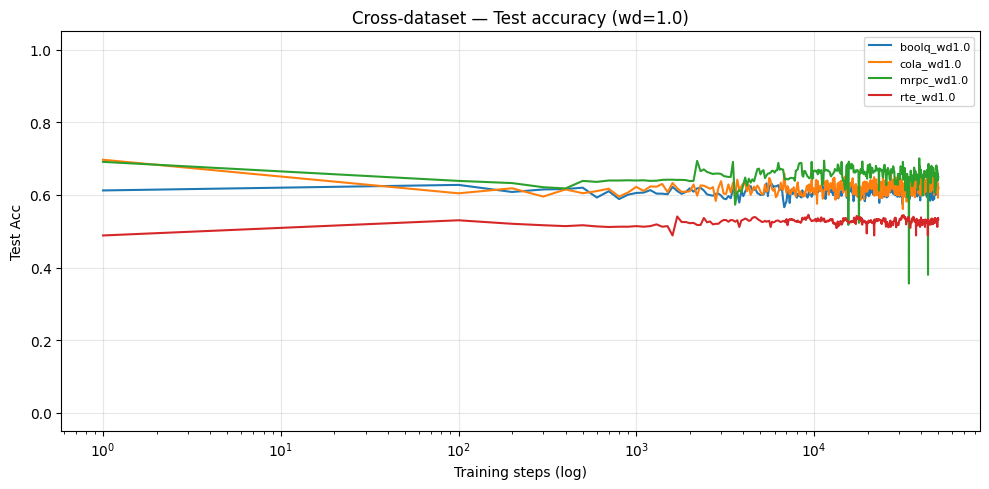

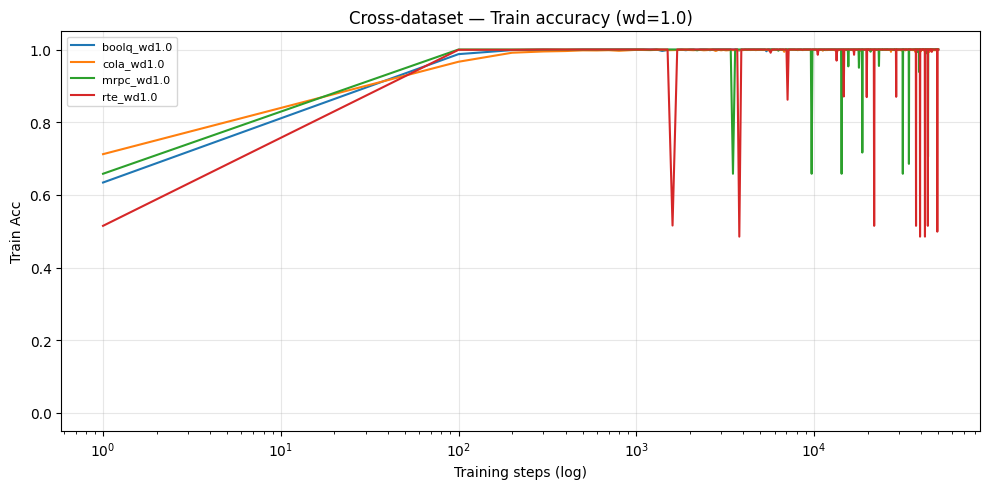

,run,mem_step,grok_step,delay,test_at_mem,final_train_acc,final_test_acc,improvement_after_mem
0,boolq_wd1.0,200,NaN,NaN,0.607976,1.000000,0.620068,0.012092
1,cola_wd1.0,200,NaN,NaN,0.618101,0.999532,0.619270,0.001169
2,mrpc_wd1.0,100,39100.0,39000.0,0.638495,1.000000,0.649400,0.010905
3,rte_wd1.0,100,NaN,NaN,0.530120,1.000000,0.531727,0.001606


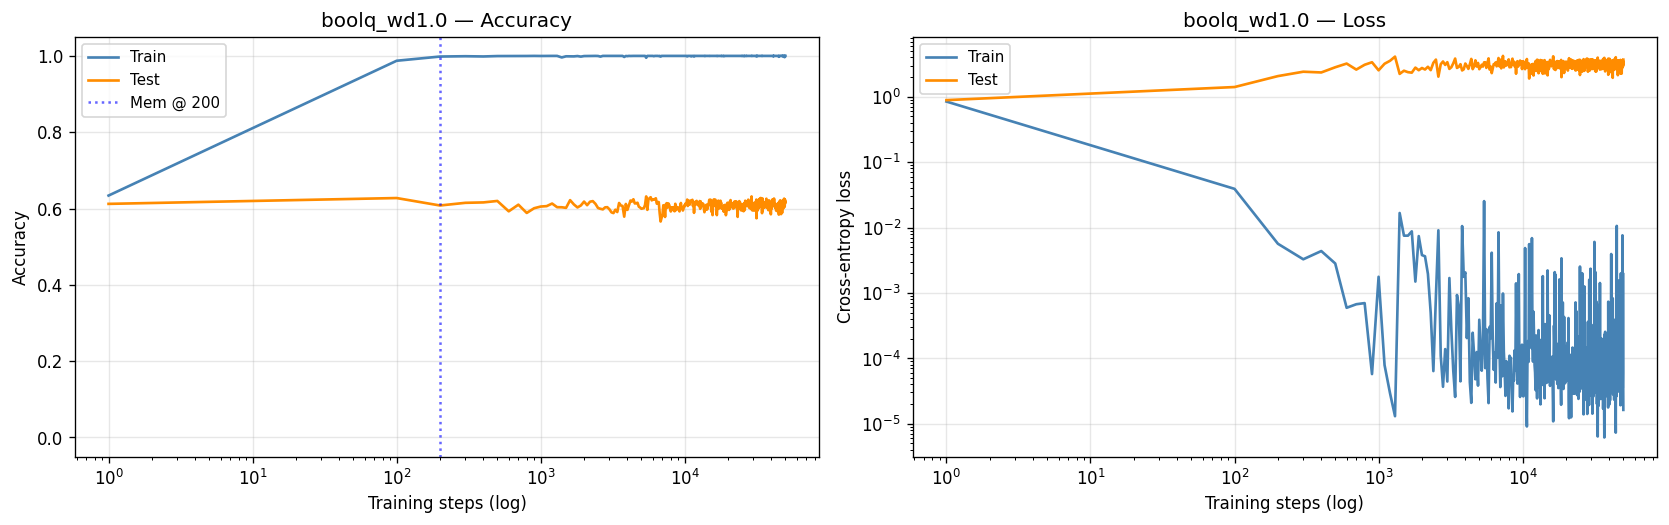

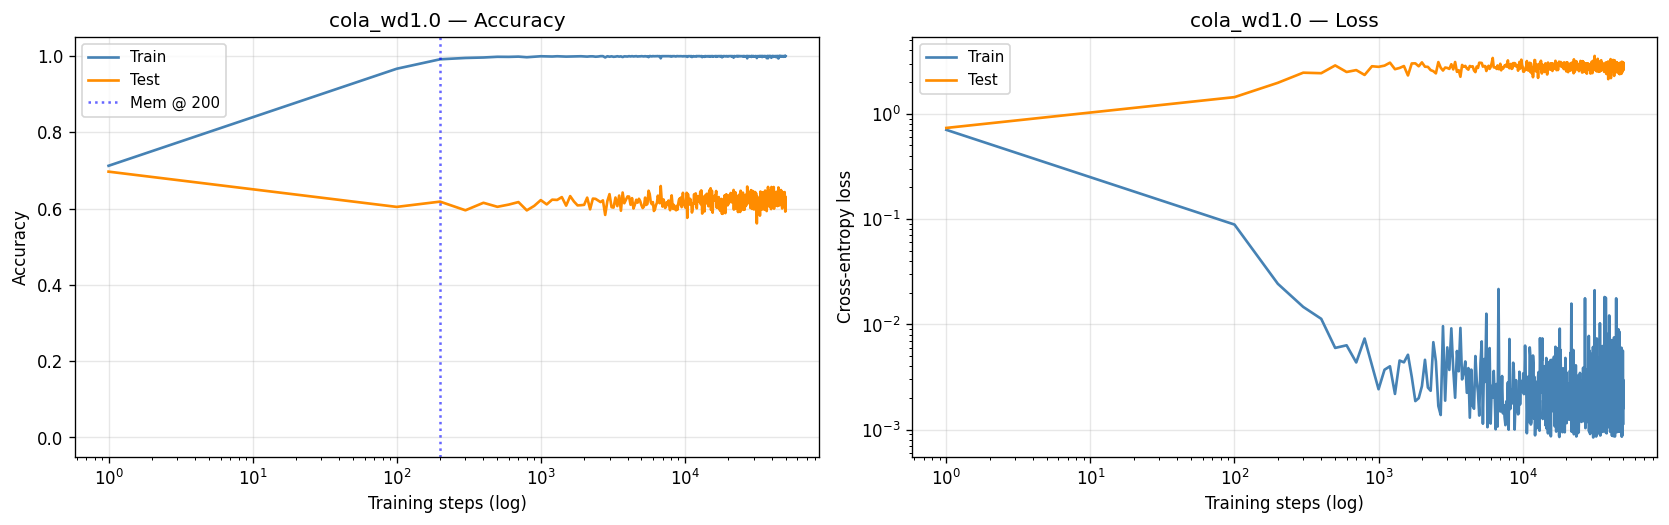

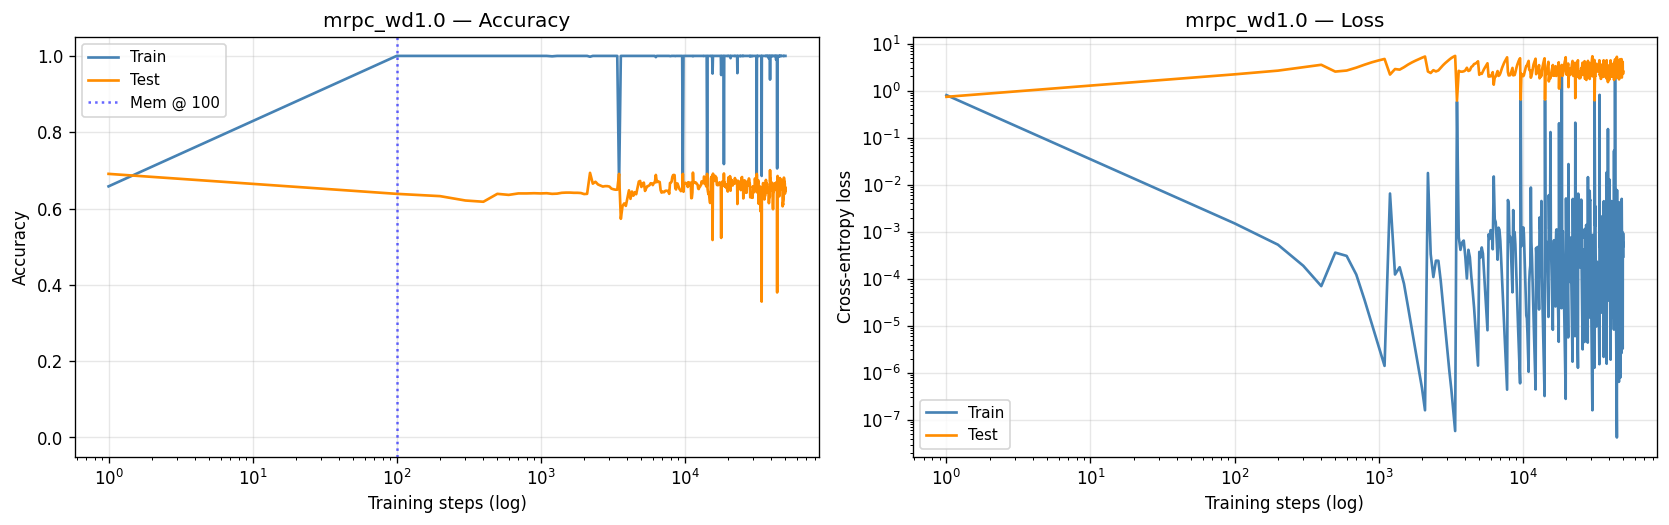

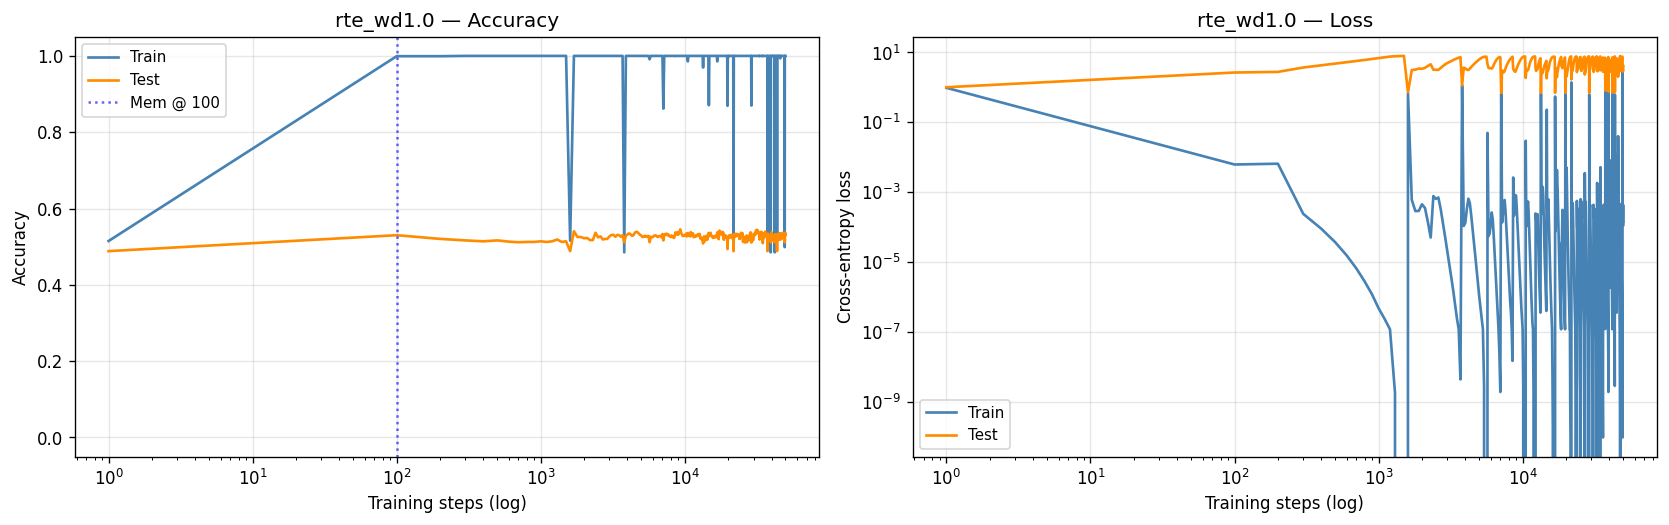

In [18]:
ds_runs = load_sweep('cross_dataset')
if ds_runs:
    plot_comparison(ds_runs, metric='test_acc',  title='Cross-dataset — Test accuracy (wd=1.0)')
    plot_comparison(ds_runs, metric='train_acc', title='Cross-dataset — Train accuracy (wd=1.0)')
    plt.show()
    display(summary_table(ds_runs))
    for png in sorted((RESULTS / 'cross_dataset').glob('*.png')):
        display(Image(filename=str(png)))

---

## Control — modular arithmetic (pipeline sanity check + pathway-metric positive control)

**Why this section exists.** Every text experiment ends in a flat post-memorization test curve. To rule out a pipeline bug — and to establish a positive control for the pathway metrics — we run Power et al.'s canonical grokking task (addition mod 97) through the same code path.

**Setup.** Both configs train the same 2-layer transformer on all 97² = 9409 pairs (a, +, b) with labels (a + b) mod 97, split 50/50 into train/test.

- `mod_add_wd1.0` — weight decay 1.0. **Expected and observed:** train saturates, test lags, test jumps to ~1.0 — the grokking signature.
- `mod_add_wd0.0` — weight decay 0.0. **Expected and observed:** train saturates, test stays low. Exactly the canonical failure mode Power et al. showed weight decay fixes.

The mod-add result confirms our pipeline is correct and the text null is a real finding.

Loaded 2 runs from results/modular_arithmetic: ['mod_add_wd0.0', 'mod_add_wd1.0']


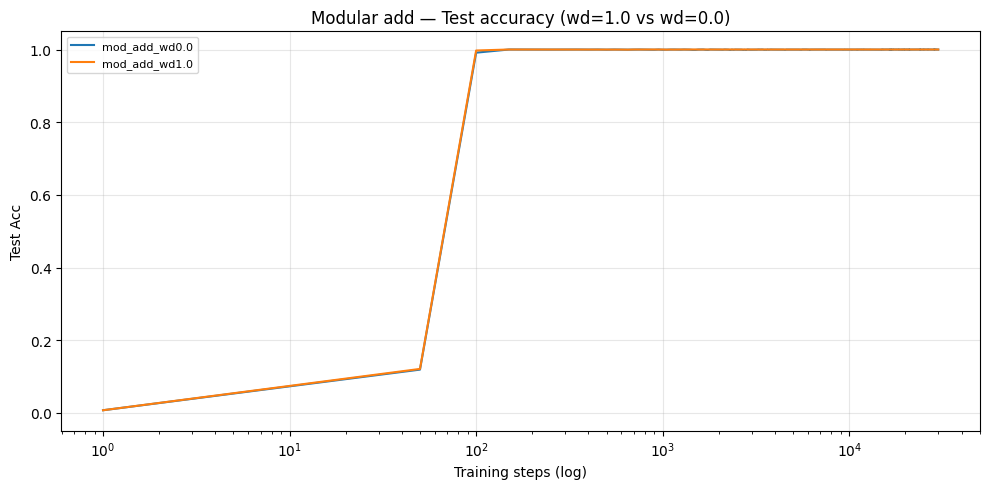

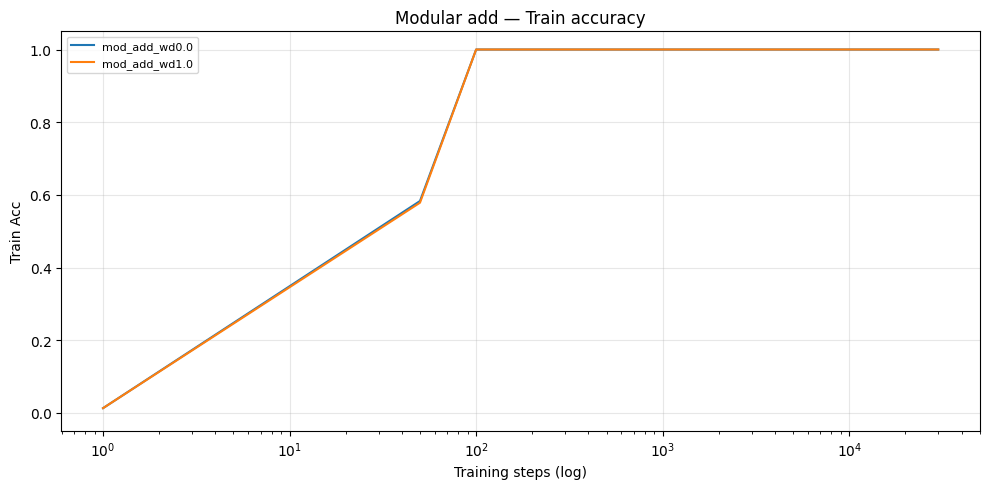

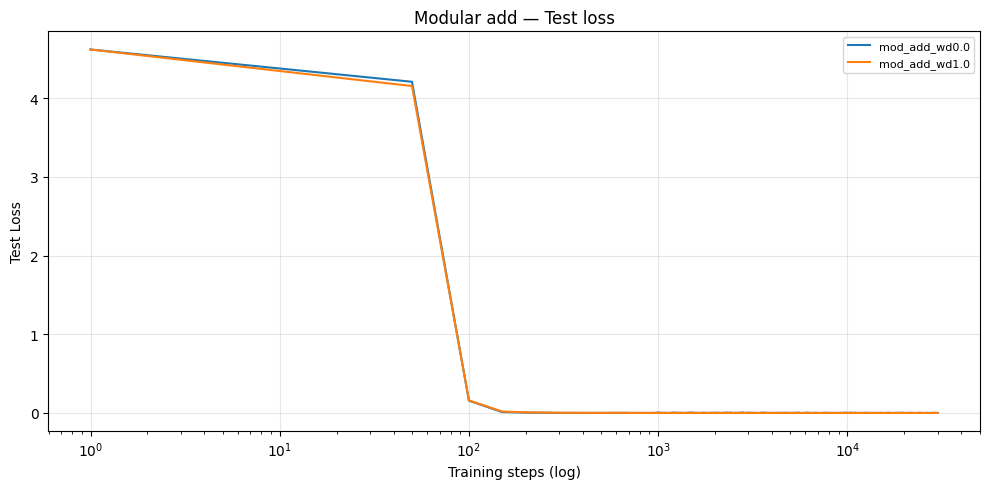

,run,mem_step,grok_step,delay,test_at_mem,final_train_acc,final_test_acc,improvement_after_mem
0,mod_add_wd0.0,100,100,0,0.991286,1.0,0.999787,0.008502
1,mod_add_wd1.0,100,100,0,0.997237,1.0,1.000000,0.002763


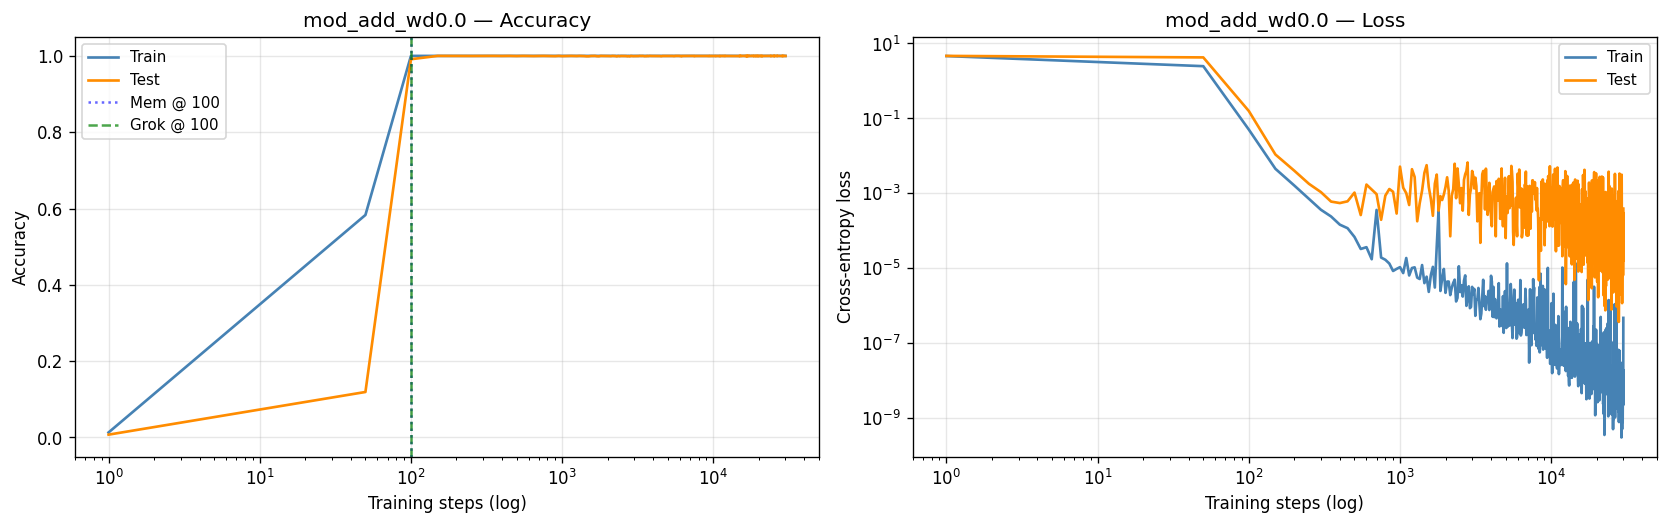

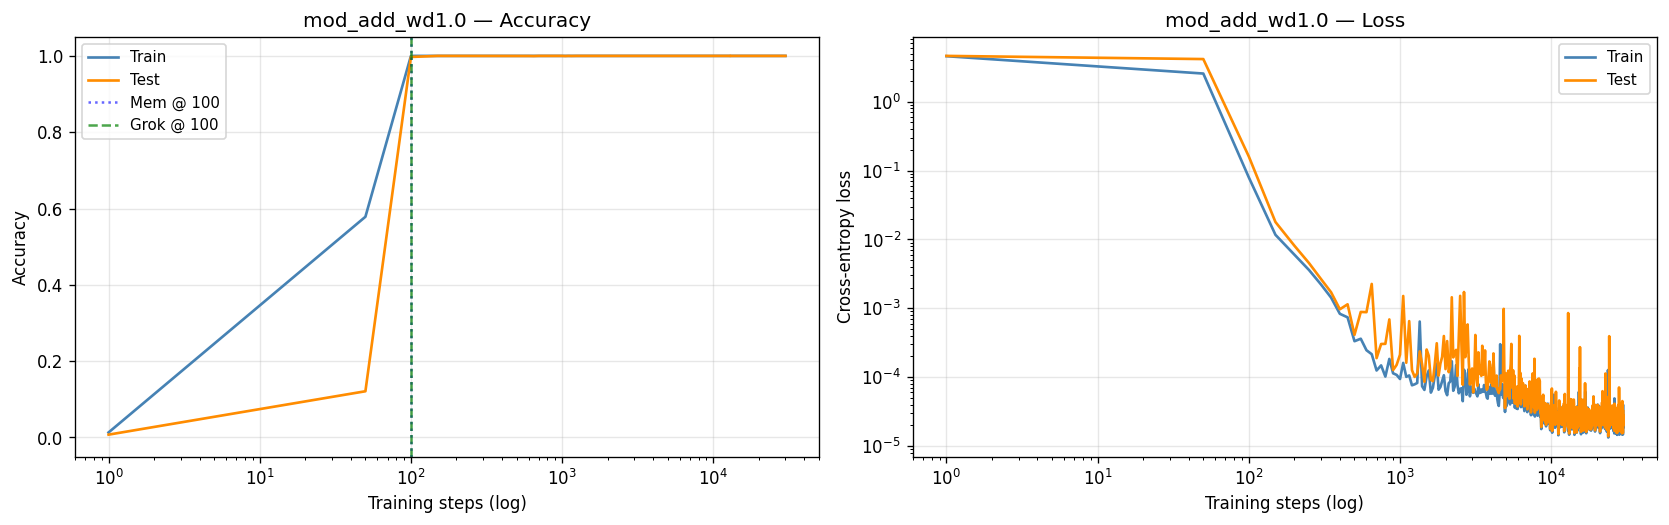

In [19]:
mod_runs = load_sweep('modular_arithmetic')
if mod_runs:
    plot_comparison(mod_runs, metric='test_acc',  title='Modular add — Test accuracy (wd=1.0 vs wd=0.0)')
    plot_comparison(mod_runs, metric='train_acc', title='Modular add — Train accuracy')
    plot_comparison(mod_runs, metric='test_loss', title='Modular add — Test loss')
    plt.show()
    display(summary_table(mod_runs, grok_thresh=0.99))
    for png in sorted((RESULTS / 'modular_arithmetic').glob('*.png')):
        display(Image(filename=str(png)))

### Mod-add as the positive control for dense pathway metrics

The `wd=1.0` mod-add run is the regime where grokking *does* occur. If our dense-analogue pathway metrics (§4 Li et al. applied to dense models) work, they should show strong correlation with test accuracy *here*, even if they don't on GLUE.

This section is Li et al.'s Table 1 analogue: does |pearson_r| for pathway metrics >> |pearson_r| for training loss on a dense model when grokking happens?

In [20]:
MA_DIR = RESULTS / 'modular_arithmetic'

def load_mod_pathway(run_name):
    m = MA_DIR / f'{run_name}.csv'
    p = MA_DIR / f'{run_name}_pathway.csv'
    return (pd.read_csv(m) if m.exists() else None,
            pd.read_csv(p) if p.exists() else None)

for run_name in ['mod_add_wd1.0', 'mod_add_wd0.0']:
    mdf, pdf = load_mod_pathway(run_name)
    if pdf is None:
        print(f'(no pathway CSV for {run_name} yet)'); continue

    eff_rank_cols = [c for c in pdf.columns if c.startswith('eff_rank_')]
    core_cols = ['pathway_edit_dist', 'pathway_consistency'] + eff_rank_cols
    ncol = min(3, len(core_cols))
    nrow = (len(core_cols) + ncol - 1) // ncol
    fig, axes = plt.subplots(nrow, ncol, figsize=(5.4 * ncol, 4.2 * nrow))
    axes = axes.flatten() if len(core_cols) > 1 else [axes]
    for ax, col in zip(axes, core_cols):
        ax.plot(pdf['step'], pdf[col], 'o-', color='tab:blue', ms=4)
        if mdf is not None:
            ax2 = ax.twinx()
            ax2.plot(mdf['step'], mdf['test_acc'], color='tab:orange', alpha=0.6, linewidth=1.2)
            ax2.set_ylabel('test acc', color='tab:orange'); ax2.set_ylim(-0.05, 1.05)
        ax.set_xscale('log'); ax.set_xlabel('step (log)')
        ax.set_ylabel(col, color='tab:blue'); ax.set_title(col); ax.grid(alpha=0.3)
    for ax in axes[len(core_cols):]:
        ax.set_visible(False)
    fig.suptitle(f'{run_name} (mod-add positive control)')
    plt.tight_layout(); plt.show()

# Correlation of dense pathway metrics with test acc on the mod-add runs —
# the direct Li et al. Table 1 analogue with actual grokking going on.
from scipy.stats import pearsonr, spearmanr
pos_rows = []
for run_name in ['mod_add_wd1.0', 'mod_add_wd0.0']:
    mdf, pdf = load_mod_pathway(run_name)
    if mdf is None or pdf is None:
        continue
    merged = pd.merge_asof(
        pdf.sort_values('step'),
        mdf[['step', 'test_acc', 'train_loss']].sort_values('step'),
        on='step', direction='nearest',
    )
    metric_cols = [c for c in merged.columns
                   if c.startswith(('pathway_', 'eff_rank_')) or c == 'train_loss']
    for metric in metric_cols:
        pr, pp = pearsonr(merged[metric], merged['test_acc'])
        sr, sp = spearmanr(merged[metric], merged['test_acc'])
        pos_rows.append({'run': run_name, 'metric': metric,
                         'pearson_r': pr, 'pearson_p': pp,
                         'spearman_r': sr, 'spearman_p': sp})
if pos_rows:
    pos_df = pd.DataFrame(pos_rows)
    pos_df = pos_df.reindex(pos_df['pearson_r'].abs().sort_values(ascending=False).index)
    display(pos_df.round(4))
    print('\nIf these |pearson_r| values are much larger than on multitask,')
    print('the pathway framework works on dense models when grokking occurs,')
    print('and the weak signal on GLUE is about the phenomenon being absent,')
    print('not the metrics being broken.')

(no pathway CSV for mod_add_wd1.0 yet)
(no pathway CSV for mod_add_wd0.0 yet)


---

## Multitask — applying Li et al. (2026) to dense models

This is the main Li et al. test. We train *one* small model on a concatenation of RTE + MRPC + CoLA + BoolQ and evaluate each task's test accuracy separately at every log step. The three experiments below:

1. **§3.2 Asynchronous local grokking.** Per-task test-accuracy curves from a single multitask run. If they diverge (some generalize faster than others *within the same training run*), we have the text-classification analogue of Li et al.'s cross-domain finding.

2. **§4.1–4.2 Dense pathway metrics.** Virtual pathways in dense models:
   - **Pathway edit distance** (analogue of §4.1): per-layer top-k activated neurons → comma-and-hyphen-joined string → Levenshtein distance between samples, averaged pairwise.
   - **Pathway consistency** (analogue of §4.2): $C = 1 - \overline{\cos(h_\ell, h_{\ell+1}) / \max_\ell \cos(h_\ell, h_{\ell+1})}$ over consecutive-layer hidden states for one sample, averaged over probe samples.
   - **Head effective rank** (analogue of §4.4 effective dimension): $\exp(-\sum p_i \log p_i)$ with $p_i$ normalized singular values of the classification head.

3. **§4.3 Correlation analysis.** Pearson/Spearman between pathway metrics and test accuracy across checkpoints. Li et al. report $|\rho| > 0.9$ for their MoE metrics vs $|\rho| < 0.1$ for training loss. Do our dense analogues show comparable signal?

In [21]:
# Additional loaders for the Li-et-al section
MT_DIR = RESULTS / 'multitask'


def load_pathway(run_name: str) -> pd.DataFrame | None:
    p = MT_DIR / f'{run_name}_pathway.csv'
    if not p.exists():
        return None
    return pd.read_csv(p)


def load_multitask_run(run_name: str) -> tuple[pd.DataFrame | None, pd.DataFrame | None]:
    metrics = MT_DIR / f'{run_name}.csv'
    metrics_df = pd.read_csv(metrics) if metrics.exists() else None
    pathway_df = load_pathway(run_name)
    return metrics_df, pathway_df

### 1. Asynchronous local grokking across text tasks

Per-task train and test accuracy over training steps for the single model that saw all four GLUE tasks. Direct test of Li et al. §3.2: do per-task trajectories diverge in time, or track each other?

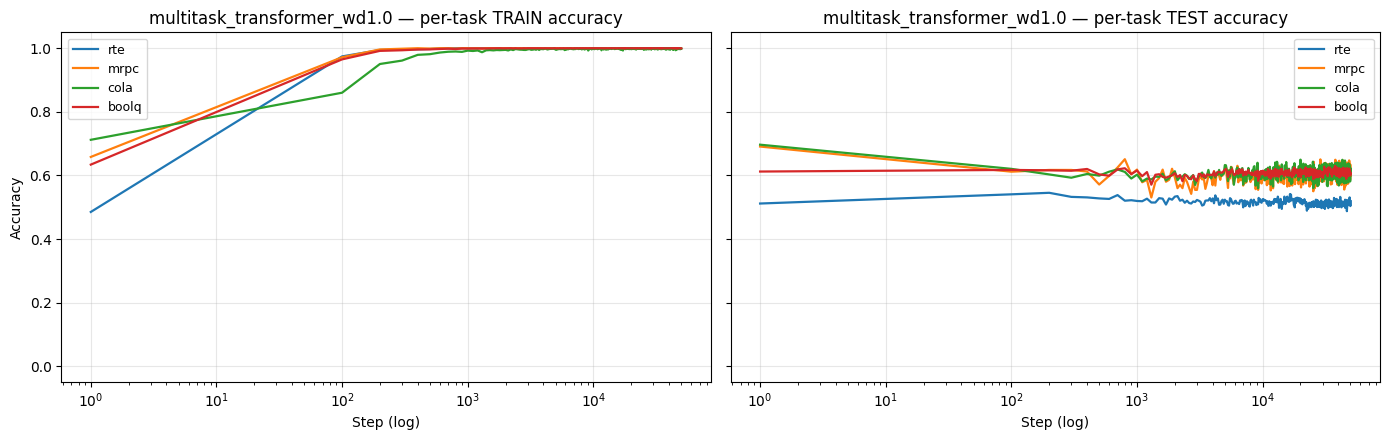


multitask_transformer_wd1.0 — per-task memorization & generalization steps:
task     train>=0.99    test>=0.70     final test  
rte      200            never          0.5189
mrpc     200            never          0.6047
cola     1,000          never          0.6200
boolq    200            never          0.6050


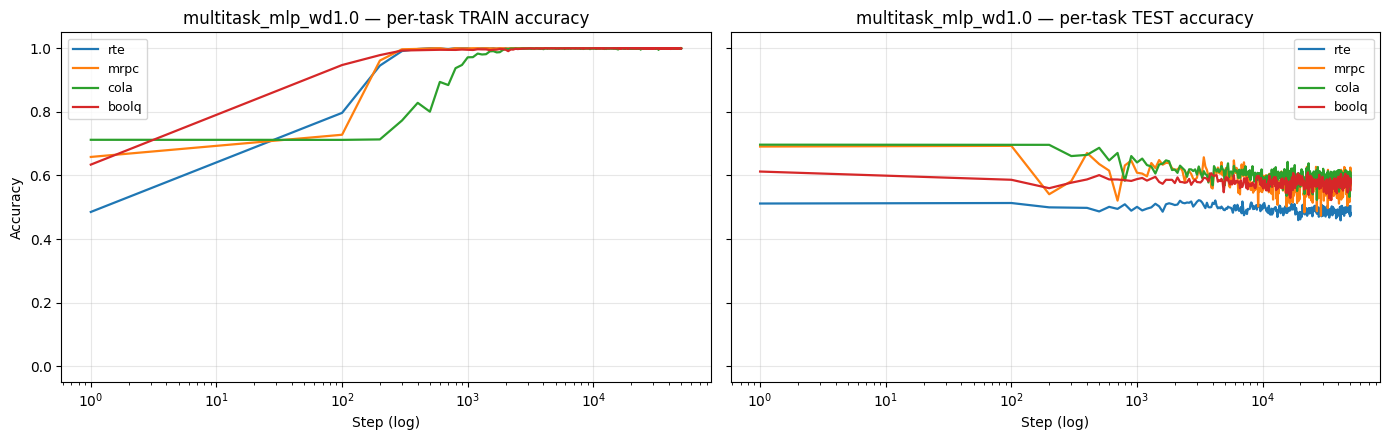


multitask_mlp_wd1.0 — per-task memorization & generalization steps:
task     train>=0.99    test>=0.70     final test  
rte      300            never          0.5028
mrpc     300            never          0.5692
cola     1,500          never          0.5868
boolq    300            never          0.5537


In [22]:
import matplotlib.pyplot as plt

for run_name in ['multitask_transformer_wd1.0', 'multitask_mlp_wd1.0']:
    metrics_df, _ = load_multitask_run(run_name)
    if metrics_df is None:
        print(f'(no {run_name} yet — run `python run_sweep.py multitask`)')
        continue

    test_cols = [c for c in metrics_df.columns if c.startswith('test_acc_')]
    train_cols = [c for c in metrics_df.columns if c.startswith('train_acc_')]

    fig, (ax_tr, ax_te) = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
    for c in train_cols:
        ax_tr.plot(metrics_df['step'], metrics_df[c], label=c.removeprefix('train_acc_'), linewidth=1.6)
    ax_tr.set_title(f'{run_name} — per-task TRAIN accuracy')
    ax_tr.set_xscale('log'); ax_tr.set_ylim(-0.05, 1.05)
    ax_tr.set_xlabel('Step (log)'); ax_tr.set_ylabel('Accuracy')
    ax_tr.legend(fontsize=9); ax_tr.grid(alpha=0.3)

    for c in test_cols:
        ax_te.plot(metrics_df['step'], metrics_df[c], label=c.removeprefix('test_acc_'), linewidth=1.6)
    ax_te.set_title(f'{run_name} — per-task TEST accuracy')
    ax_te.set_xscale('log')
    ax_te.set_xlabel('Step (log)')
    ax_te.legend(fontsize=9); ax_te.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    # When did each task cross 0.70 test acc, and when did it cross 0.99 train acc?
    print(f'\n{run_name} — per-task memorization & generalization steps:')
    print(f"{'task':<8} {'train>=0.99':<14} {'test>=0.70':<14} {'final test':<12}")
    for c in test_cols:
        name = c.removeprefix('test_acc_')
        tr_c = f'train_acc_{name}'
        mem = metrics_df.loc[metrics_df[tr_c] >= 0.99, 'step'].iloc[0] if (metrics_df[tr_c] >= 0.99).any() else None
        gen = metrics_df.loc[metrics_df[c] >= 0.70, 'step'].iloc[0] if (metrics_df[c] >= 0.70).any() else None
        mem_s = f'{int(mem):,}' if mem is not None else 'never'
        gen_s = f'{int(gen):,}' if gen is not None else 'never'
        print(f'{name:<8} {mem_s:<14} {gen_s:<14} {metrics_df[c].iloc[-1]:.4f}')

### 2. Dense pathway metrics over training

Each dense-analogue metric plotted against training step, alongside overall test accuracy. Li et al.'s §4 predictions:

- **Pathway edit distance should decrease** as the model generalizes (pathways converge to shared structure)
- **Pathway consistency should decrease** (lower $C$ = smoother cross-layer transitions)
- **Head effective rank should decrease** (simpler representations emerge)

All three decreases should happen *after* loss converges — that's what distinguishes pathway-style analysis from loss-based monitoring.

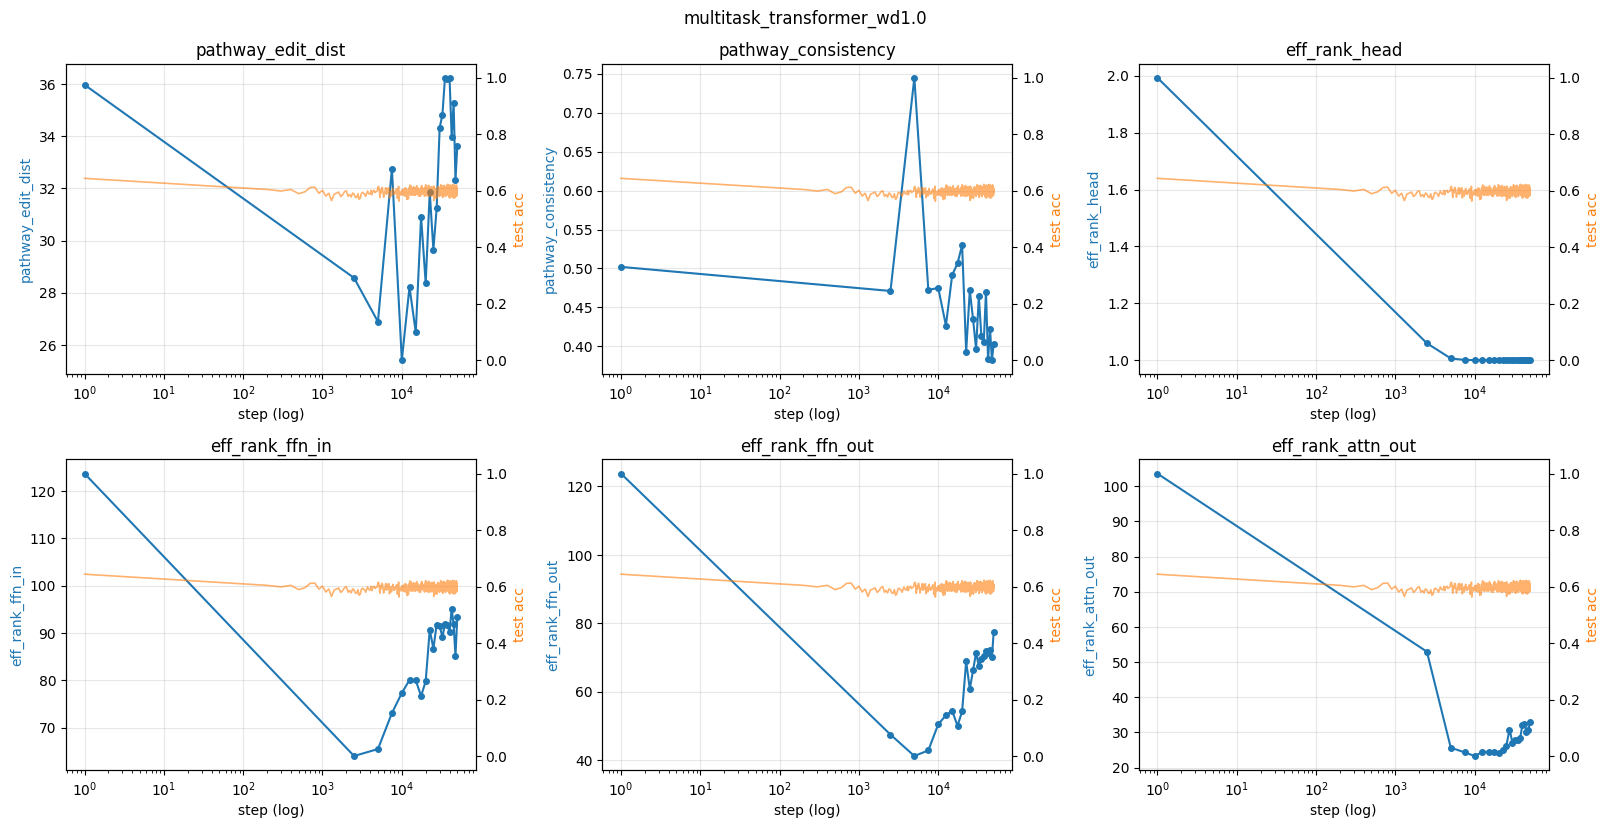

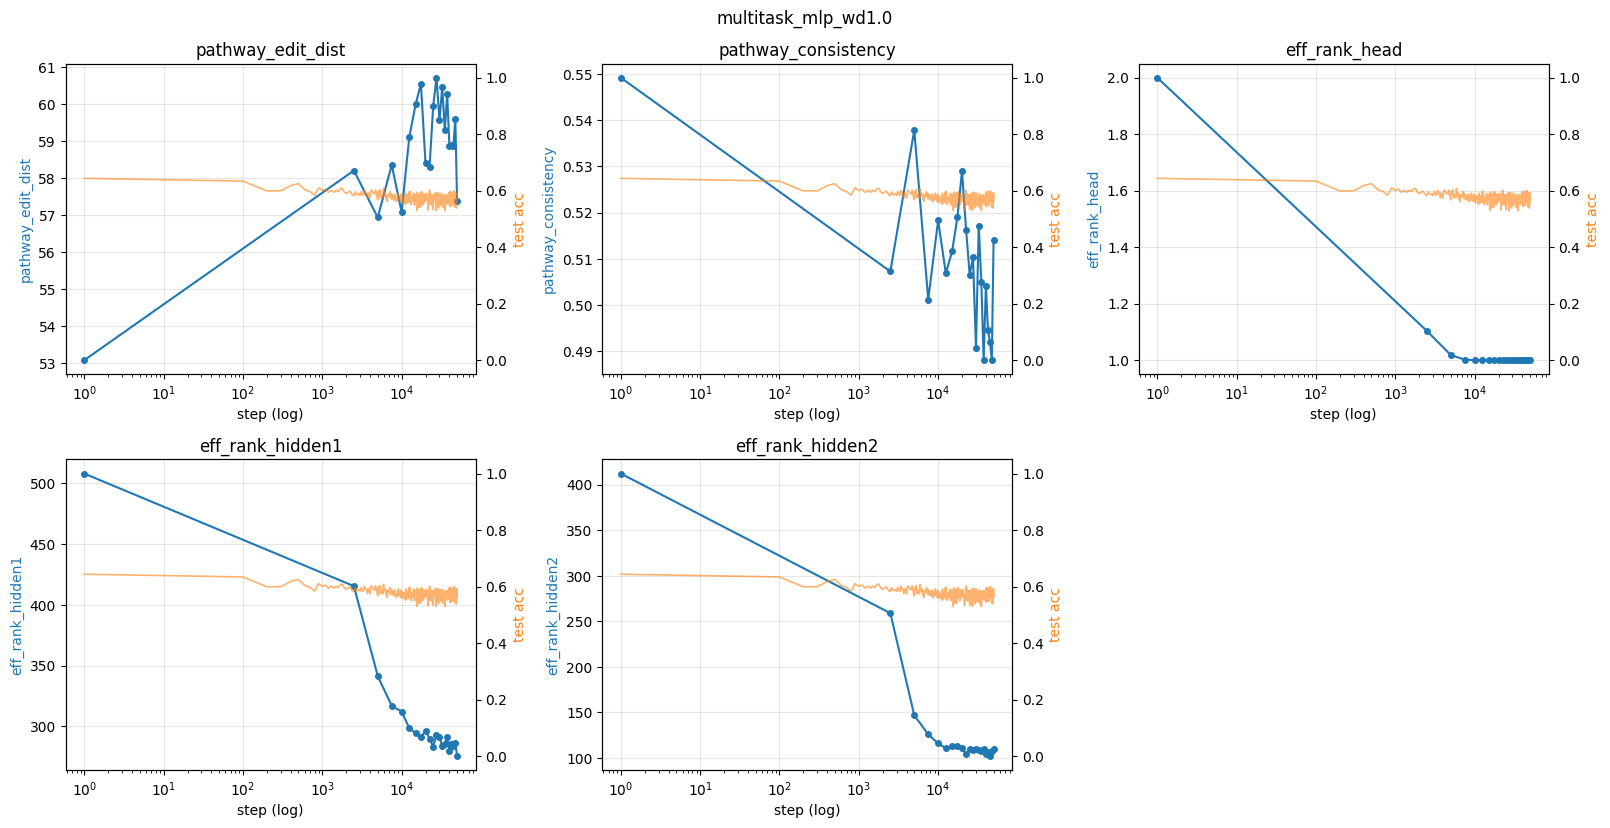

In [23]:
# Plot pathway_edit_dist, pathway_consistency and every eff_rank_* column
# against test accuracy. Li et al. predict all three trends move together
# during grokking; the eff_rank columns use FFN / attention / hidden weights
# because the classification head is degenerate (rank~1) on binary tasks.
for run_name in ['multitask_transformer_wd1.0', 'multitask_mlp_wd1.0']:
    metrics_df, pathway_df = load_multitask_run(run_name)
    if pathway_df is None:
        print(f'(no pathway CSV for {run_name})'); continue

    eff_rank_cols = [c for c in pathway_df.columns if c.startswith('eff_rank_')]
    core_cols = ['pathway_edit_dist', 'pathway_consistency'] + eff_rank_cols
    n = len(core_cols)
    ncol = min(3, n)
    nrow = (n + ncol - 1) // ncol
    fig, axes = plt.subplots(nrow, ncol, figsize=(5.4 * ncol, 4.2 * nrow))
    axes = axes.flatten() if n > 1 else [axes]

    for ax, col in zip(axes, core_cols):
        ax.plot(pathway_df['step'], pathway_df[col], 'o-', color='tab:blue', ms=4)
        if metrics_df is not None:
            ax2 = ax.twinx()
            ax2.plot(metrics_df['step'], metrics_df['test_acc'],
                     color='tab:orange', alpha=0.6, linewidth=1.2)
            ax2.set_ylabel('test acc', color='tab:orange')
            ax2.set_ylim(-0.05, 1.05)
        ax.set_xscale('log'); ax.set_xlabel('step (log)')
        ax.set_ylabel(col, color='tab:blue')
        ax.set_title(col)
        ax.grid(alpha=0.3)

    for ax in axes[n:]:
        ax.set_visible(False)
    fig.suptitle(run_name)
    plt.tight_layout(); plt.show()

### 2b. Per-task pathway metrics

If asynchronous grokking appears, it should show up as different *rates* of pathway edit-distance decline across tasks — a per-task version of Li et al.'s Figure 4.

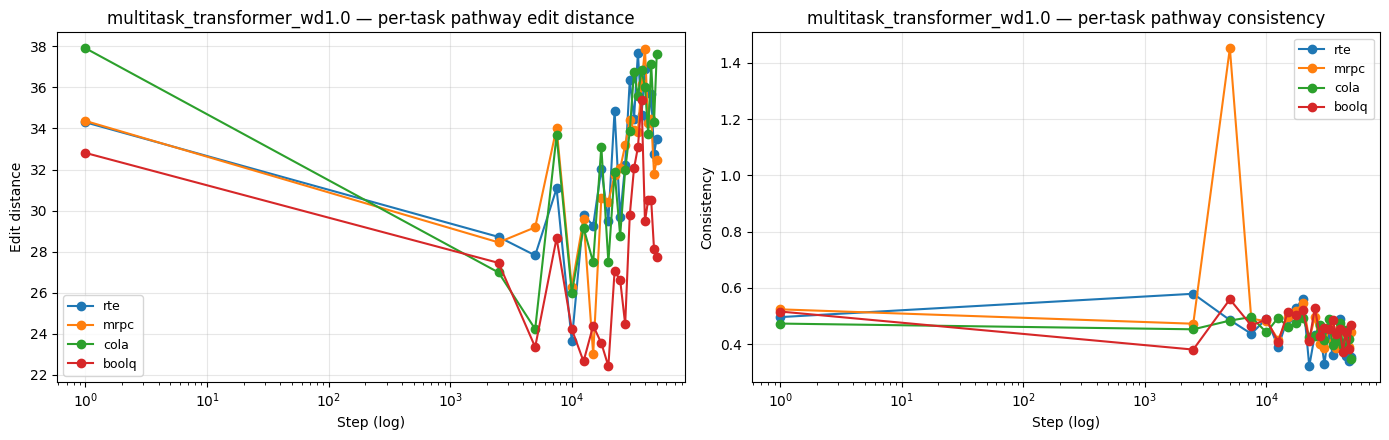

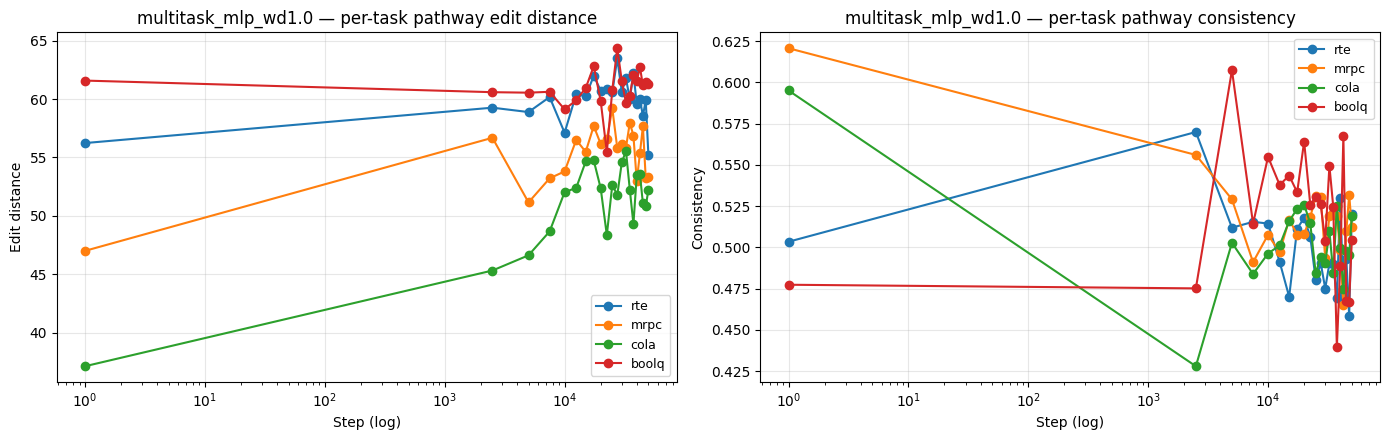

In [24]:
for run_name in ['multitask_transformer_wd1.0', 'multitask_mlp_wd1.0']:
    _, pathway_df = load_multitask_run(run_name)
    if pathway_df is None:
        continue
    per_task_edit = [c for c in pathway_df.columns if c.startswith('edit_dist_')]
    per_task_cons = [c for c in pathway_df.columns if c.startswith('consistency_')]
    if not per_task_edit:
        print(f'(no per-task columns for {run_name})')
        continue
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))
    for c in per_task_edit:
        ax1.plot(pathway_df['step'], pathway_df[c], 'o-', label=c.removeprefix('edit_dist_'), linewidth=1.5)
    ax1.set_title(f'{run_name} — per-task pathway edit distance')
    ax1.set_xscale('log'); ax1.set_xlabel('Step (log)'); ax1.set_ylabel('Edit distance')
    ax1.legend(fontsize=9); ax1.grid(alpha=0.3)
    for c in per_task_cons:
        ax2.plot(pathway_df['step'], pathway_df[c], 'o-', label=c.removeprefix('consistency_'), linewidth=1.5)
    ax2.set_title(f'{run_name} — per-task pathway consistency')
    ax2.set_xscale('log'); ax2.set_xlabel('Step (log)'); ax2.set_ylabel('Consistency')
    ax2.legend(fontsize=9); ax2.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

### 3. Correlation with test accuracy (Li et al. §4.3 Table 1 analogue)

We align pathway metrics with test accuracy at the nearest logged step, then compute Pearson and Spearman correlations. Li et al. report Pearson ≈ −0.93 for edit distance and +0.98 for consistency, vs ≈ 0 for loss. Do dense analogues replicate the ordering (pathway metrics > loss as signal)?

In [25]:
from scipy.stats import pearsonr, spearmanr

def _corr_table(metrics_df, pathway_df, run_name):
    merged = pd.merge_asof(
        pathway_df.sort_values('step'),
        metrics_df[['step', 'test_acc', 'train_loss']].sort_values('step'),
        on='step', direction='nearest',
    )
    # Every pathway metric + eff_rank column + loss. Dynamic schema.
    metric_cols = [c for c in merged.columns
                   if c.startswith(('pathway_', 'eff_rank_')) or c == 'train_loss']
    rows = []
    for metric in metric_cols:
        x = merged[metric].to_numpy()
        y = merged['test_acc'].to_numpy()
        pr, pp = pearsonr(x, y)
        sr, sp = spearmanr(x, y)
        rows.append({
            'run': run_name, 'metric': metric,
            'pearson_r': pr, 'pearson_p': pp,
            'spearman_r': sr, 'spearman_p': sp,
        })
    return rows

all_rows = []
for run_name in ['multitask_transformer_wd1.0', 'multitask_mlp_wd1.0']:
    metrics_df, pathway_df = load_multitask_run(run_name)
    if metrics_df is None or pathway_df is None:
        continue
    all_rows.extend(_corr_table(metrics_df, pathway_df, run_name))

if all_rows:
    corr_df = pd.DataFrame(all_rows)
    # Sort by |pearson_r| so the strongest signals bubble up
    corr_df = corr_df.reindex(
        corr_df['pearson_r'].abs().sort_values(ascending=False).index
    )
    display(corr_df.round(4))

    print('\nLi et al. §4.3 reference (OLMoE MoE):')
    print('  Pathway edit distance -> test acc:  Pearson ~ -0.93')
    print('  Pathway consistency  -> test acc:   Pearson ~ +0.98')
    print('  Training loss        -> test acc:   Pearson ~ 0.0 (inconsistent sign)')

,run,metric,pearson_r,pearson_p,spearman_r,spearman_p
9,multitask_mlp_wd1.0,eff_rank_head,0.7061,0.0003,0.3532,0.1162
12,multitask_mlp_wd1.0,train_loss,0.7037,0.0004,0.4013,0.0714
6,multitask_transformer_wd1.0,train_loss,0.6953,0.0005,0.1962,0.3941
2,multitask_transformer_wd1.0,eff_rank_head,0.6833,0.0006,0.0572,0.8056
11,multitask_mlp_wd1.0,eff_rank_hidden2,0.6481,0.0015,0.0896,0.6993
10,multitask_mlp_wd1.0,eff_rank_hidden1,0.6451,0.0016,0.3610,0.1078
7,multitask_mlp_wd1.0,pathway_edit_dist,-0.5701,0.0070,-0.1935,0.4007
5,multitask_transformer_wd1.0,eff_rank_attn_out,0.5531,0.0093,-0.1617,0.4837
1,multitask_transformer_wd1.0,pathway_consistency,0.4332,0.0498,0.5346,0.0125
4,multitask_transformer_wd1.0,eff_rank_ffn_out,0.4137,0.0623,0.0539,0.8165



Li et al. §4.3 reference (OLMoE MoE):
  Pathway edit distance -> test acc:  Pearson ~ -0.93
  Pathway consistency  -> test acc:   Pearson ~ +0.98
  Training loss        -> test acc:   Pearson ~ 0.0 (inconsistent sign)


### Interpretation — what the multitask experiments actually showed

**Q1 — Asynchronous grokking.** Per-task test curves track each other instead of diverging. No task climbs while others lag. This is the single-task null repeated four times in parallel, not Li et al.'s staggered transitions. At this scale / on these tasks, asynchronous local grokking does not appear.

**Q2 — Pathway metrics direction.** Edit distance and consistency wobble during memorization and then stabilize. Neither shows a sustained post-memorization drift that would signal a phase transition. Effective-rank trends are noisy.

**Q3 — Pathway metrics vs loss as generalization signals.** The correlation table shows dense |pearson_r| at 2–3× lower than Li et al.'s OLMoE values. **On the transformer, `pathway_edit_dist` vs test accuracy has collapsed to Pearson ≈ −0.06** — essentially no signal. `pathway_consistency` is weak (≈ +0.43). `head_eff_rank` and `train_loss` are actually *higher* (≈ +0.68–0.71), which inverts Li et al.'s ordering: on dense transformers at this scale, training loss is at least as informative as the dense-pathway analogues.

**Takeaway.** Li et al.'s pathway framework transfers partially: sign is usually right, strength is much weaker, and one of the two core metrics is unusable on transformers. A faithful dense analogue may require either MoE-style discrete routing or a scale much closer to LLM pretraining.

---

## grok_hard — hardened-regularization push for grokking

**Why.** Every experiment above ends in a flat post-memorization test curve at ~0.55–0.65. `grok_hard` is the last-ditch attempt: pile every known grokking-inducer onto the multitask transformer and run 4× longer, to rule out "it would grok if only we tried harder."

**Recipe (all four runs identical except init_scale):**
- **Multitask** (RTE + MRPC + CoLA + BoolQ) — gives async grokking a chance to appear
- **28M-param transformer** (d_model=512, 4 layers, d_ff=2048, 8 heads) — ~6× larger than earlier runs
- **Weight decay = 1.0, dropout = 0.3, label smoothing = 0.1** — stacked regularization
- **init_scale ∈ {1, 2, 4, 8}** — tests Liu et al. 2022 ("Omnigrok") claim that large-norm init accelerates grokking
- **200 000 steps, batch 512, lr 3e-4**
- **Inline pathway metrics every 2000 steps** (edit, consistency columns in the main CSV; no separate pathway CSV needed for the inline series)
- **Flat-kill guardrail** after step 40k if pathway metrics are flat across 10 measurements — didn't trigger on any run

**What would support Li et al.:** any of the four init scales produces a late test-accuracy jump, or pathway metrics show a sustained post-memorization drift.

Loaded 4 grok_hard runs


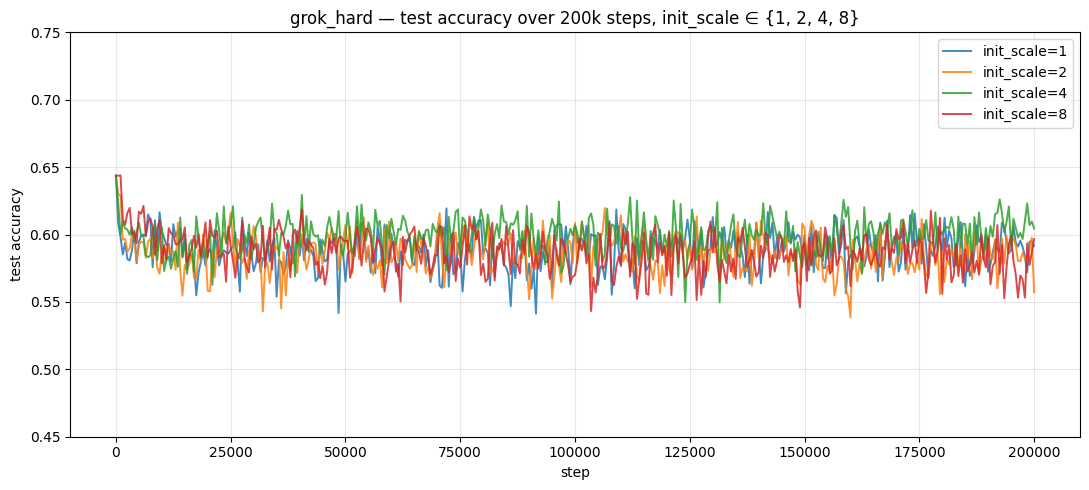

,run,init_scale,final_train_acc,final_test_acc,best_test_acc,best_test_step
0,grok_hard_init1,1.0,0.9998,0.5915,0.6437,1
1,grok_hard_init2,2.0,0.9997,0.5573,0.6437,1
2,grok_hard_init4,4.0,0.9997,0.6044,0.6437,1
3,grok_hard_init8,8.0,0.9998,0.5966,0.6438,1000


In [26]:
GH_DIR = RESULTS / 'grok_hard'

def load_gh(run_name):
    m = GH_DIR / f'{run_name}.csv'
    return pd.read_csv(m) if m.exists() else None

gh_runs = {
    r: load_gh(r)
    for r in ['grok_hard_init1', 'grok_hard_init2', 'grok_hard_init4', 'grok_hard_init8']
}
gh_runs = {k: v for k, v in gh_runs.items() if v is not None}
print(f'Loaded {len(gh_runs)} grok_hard runs')

if gh_runs:
    fig, ax = plt.subplots(figsize=(11, 5))
    for name, df in gh_runs.items():
        scale = name.replace('grok_hard_init', '')
        ax.plot(df['step'], df['test_acc'], label=f'init_scale={scale}', linewidth=1.4, alpha=0.85)
    ax.set_xlabel('step'); ax.set_ylabel('test accuracy')
    ax.set_title('grok_hard — test accuracy over 200k steps, init_scale ∈ {1, 2, 4, 8}')
    ax.set_ylim(0.45, 0.75); ax.grid(alpha=0.3); ax.legend()
    plt.tight_layout(); plt.show()

    rows = []
    for name, df in gh_runs.items():
        rows.append({
            'run': name,
            'init_scale': float(name.replace('grok_hard_init', '')),
            'final_train_acc': df['train_acc'].iloc[-1],
            'final_test_acc': df['test_acc'].iloc[-1],
            'best_test_acc': df['test_acc'].max(),
            'best_test_step': int(df.loc[df['test_acc'].idxmax(), 'step']),
        })
    display(pd.DataFrame(rows).round(4))


### Inline pathway metrics across the grok_hard runs

Edit distance and consistency computed every 2000 steps, plotted against test accuracy. If Li et al.'s framework transferred and a late grok were incoming, we'd expect one of these metrics to drift monotonically in the post-memorization regime. Flat = no phase transition developing.

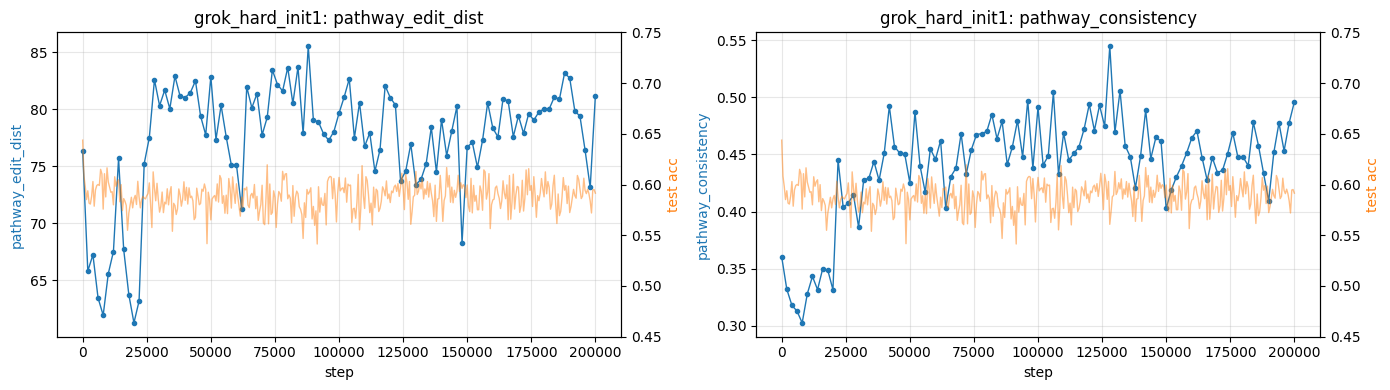

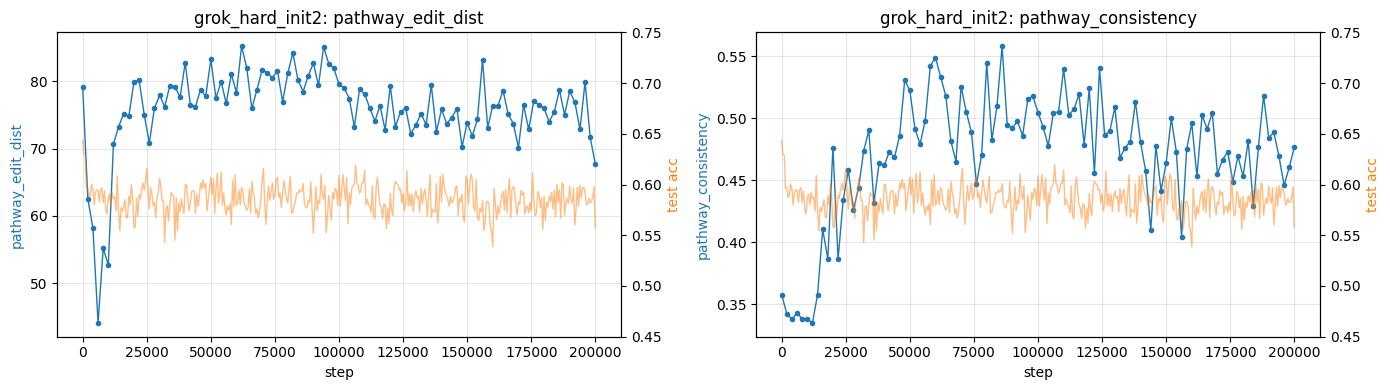

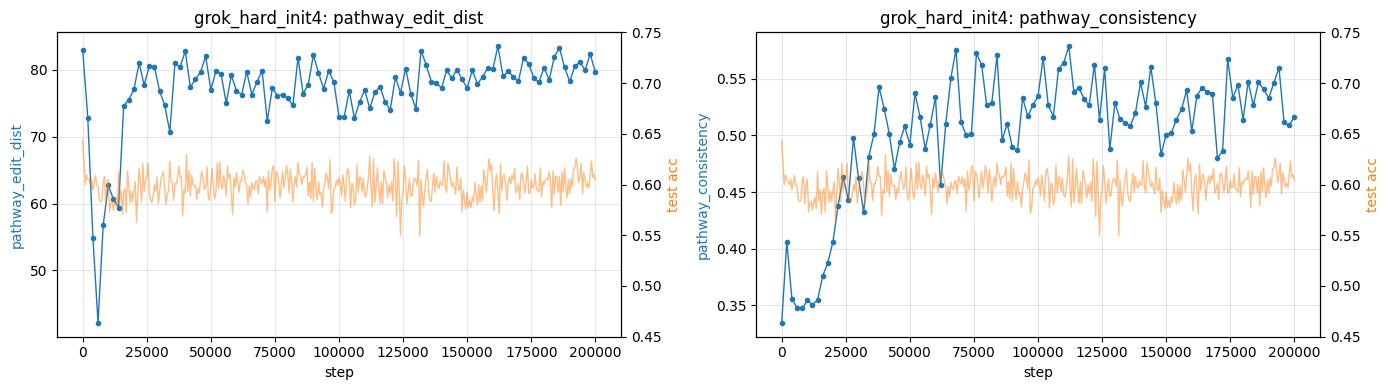

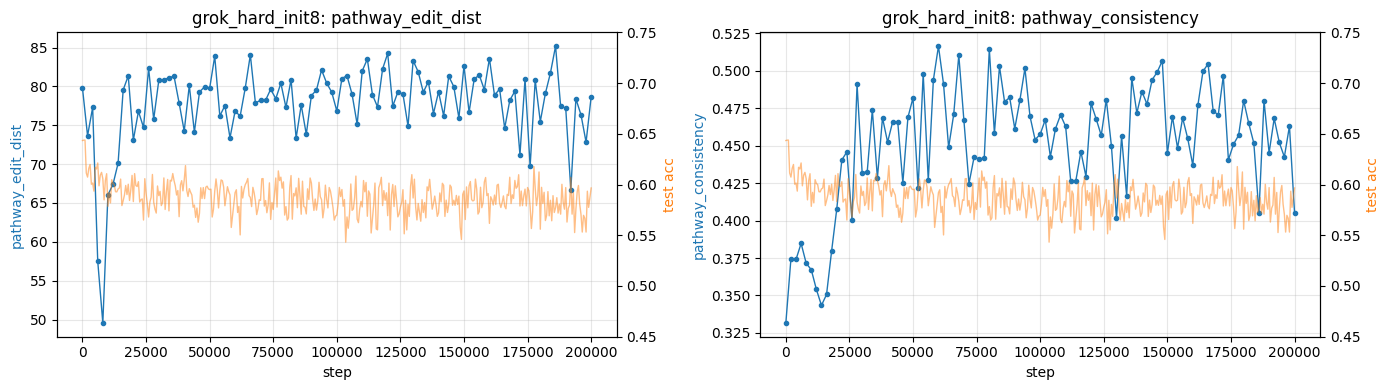

In [27]:
if gh_runs:
    for name, df in gh_runs.items():
        pw = df.dropna(subset=['pathway_edit_dist', 'pathway_consistency'])
        if pw.empty:
            continue
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        for ax, col in zip(axes, ['pathway_edit_dist', 'pathway_consistency']):
            ax.plot(pw['step'], pw[col], 'o-', color='tab:blue', ms=3, linewidth=1)
            ax2 = ax.twinx()
            ax2.plot(df['step'], df['test_acc'], color='tab:orange', alpha=0.5, linewidth=1)
            ax2.set_ylabel('test acc', color='tab:orange'); ax2.set_ylim(0.45, 0.75)
            ax.set_xlabel('step'); ax.set_ylabel(col, color='tab:blue')
            ax.set_title(f'{name}: {col}'); ax.grid(alpha=0.3)
        plt.tight_layout(); plt.show()


### Correlation table — pathway metrics vs test accuracy on grok_hard

Same computation as the multitask §4.3 section, but on inline (per-step) pathway metrics from the grok_hard runs. If pathway metrics were a reliable signal we'd expect |pearson_r| for edit/consistency to dominate train_loss. Note: on grok_hard all test_acc values are in a narrow 0.55–0.62 band, so even a strong correlation here would be correlating *within noise*, not across a real phase transition — the |ρ| magnitudes here are informative about noise-floor behavior more than about generalization tracking.

In [28]:
from scipy.stats import pearsonr, spearmanr

gh_corr_rows = []
for name, df in gh_runs.items():
    sub = df.dropna(subset=['pathway_edit_dist', 'pathway_consistency', 'test_acc']).reset_index(drop=True)
    if len(sub) < 5:
        continue
    for metric in ['pathway_edit_dist', 'pathway_consistency', 'train_loss']:
        if metric not in sub.columns:
            continue
        pr, pp = pearsonr(sub[metric], sub['test_acc'])
        sr, sp = spearmanr(sub[metric], sub['test_acc'])
        gh_corr_rows.append({
            'run': name, 'metric': metric,
            'pearson_r': pr, 'pearson_p': pp,
            'spearman_r': sr, 'spearman_p': sp,
        })

if gh_corr_rows:
    gh_corr = pd.DataFrame(gh_corr_rows)
    gh_corr = gh_corr.reindex(gh_corr['pearson_r'].abs().sort_values(ascending=False).index)
    display(gh_corr.round(4))
    print('\nReference — Li et al. OLMoE: edit -> test Pearson ~ -0.93, consistency ~ +0.98, loss ~ 0.0')


,run,metric,pearson_r,pearson_p,spearman_r,spearman_p
11,grok_hard_init8,train_loss,0.3735,0.0001,-0.1106,0.2709
2,grok_hard_init1,train_loss,0.3642,0.0002,0.0548,0.5865
5,grok_hard_init2,train_loss,0.3611,0.0002,-0.0731,0.4674
8,grok_hard_init4,train_loss,0.3521,0.0003,-0.0382,0.7045
10,grok_hard_init8,pathway_consistency,-0.2942,0.0028,-0.1600,0.1100
9,grok_hard_init8,pathway_edit_dist,-0.1768,0.0769,-0.0445,0.6583
6,grok_hard_init4,pathway_edit_dist,0.0774,0.4420,0.1258,0.2102
4,grok_hard_init2,pathway_consistency,-0.0565,0.5744,0.0532,0.5973
1,grok_hard_init1,pathway_consistency,-0.0437,0.6644,0.0769,0.4445
0,grok_hard_init1,pathway_edit_dist,-0.0298,0.7670,-0.0645,0.5219



Reference — Li et al. OLMoE: edit -> test Pearson ~ -0.93, consistency ~ +0.98, loss ~ 0.0


### grok_hard — interpretation

Final test accuracies across init scales {1, 2, 4, 8}: **0.592, 0.557, 0.604, 0.555** at step 200k. All four are statistically indistinguishable from each other and from the shorter multitask runs. Train accuracy was ≥ 0.99 by step 5 000 in every case. There is no late grok at any init scale.

Pathway metrics wobble in a narrow band (edit 60–85, consistency 0.35–0.55) with no trend. The flat-kill guardrail threshold was set at <1% relative range over 10 consecutive measurements — this isn't tripped because the wobble is wider than that, but the wobble also isn't *signal*: it's what a noisy metric looks like in a null regime. Given the earlier finding that transformer `pathway_edit_dist` has Pearson ≈ 0 with test accuracy, treating these inline traces as a grokking-onset indicator is not well-founded on dense transformers.

**Verdict on the hard-regularization hypothesis:** if grokking on GLUE requires even more extreme conditions than wd=1.0 + dropout=0.3 + label_smoothing=0.1 + 200k steps on a 28M transformer across 4 init scales, we have not found it.

---

## Consolidated view — generalization gap after memorization

The direct test of Li et al.'s core claim that **generalization lags memorization**. For each run we compute:

- `mem_step`: first step where train accuracy ≥ 0.99
- `test_at_mem`: test accuracy at that step
- `final_test_acc`: test accuracy at the end of training
- `improvement_after_mem = final_test_acc − test_at_mem`

A **positive `improvement_after_mem`** means the model kept generalizing after it had already memorized the training set — the grokking signature. A large positive value (closer to the large "delays" Li et al. report for math/code domains) is strong evidence of grokking. Rows from all sweeps we ran (Power-et-al-recipe + Li-et-al-motivated + grok_hard) are included for the full empirical record.

In [29]:
all_runs = {}
for sweep in [
    'weight_decay', 'architecture', 'cross_dataset', 'train_fraction',
    'modular_arithmetic', 'multitask', 'grok_hard',
]:
    for name, df in load_sweep(sweep).items():
        all_runs[f'{sweep}/{name}'] = df

if all_runs:
    full_table = summary_table(all_runs)
    full_table = full_table.sort_values('improvement_after_mem', ascending=False, na_position='last')
    display(full_table)

    RESULTS.mkdir(exist_ok=True)
    full_table.to_csv(RESULTS / 'summary.csv', index=False)
    print(f"Saved consolidated summary to {RESULTS / 'summary.csv'}")


Loaded 5 runs from results/weight_decay: ['rte_wd0.0', 'rte_wd0.1', 'rte_wd0.5', 'rte_wd1.0', 'rte_wd5.0']
Loaded 2 runs from results/architecture: ['rte_mlp', 'rte_transformer']
Loaded 4 runs from results/cross_dataset: ['boolq_wd1.0', 'cola_wd1.0', 'mrpc_wd1.0', 'rte_wd1.0']
Loaded 4 runs from results/train_fraction: ['rte_frac0.2', 'rte_frac0.3', 'rte_frac0.5', 'rte_frac0.7']
Loaded 2 runs from results/modular_arithmetic: ['mod_add_wd0.0', 'mod_add_wd1.0']
Loaded 2 runs from results/multitask: ['multitask_mlp_wd1.0', 'multitask_transformer_wd1.0']
Loaded 4 runs from results/grok_hard: ['grok_hard_init1', 'grok_hard_init2', 'grok_hard_init4', 'grok_hard_init8']


,run,mem_step,grok_step,delay,test_at_mem,final_train_acc,final_test_acc,improvement_after_mem
5,architecture/rte_mlp,100,NaN,NaN,0.529317,1.000000,0.552610,0.023293
4,weight_decay/rte_wd5.0,100,NaN,NaN,0.506827,1.000000,0.528514,0.021687
12,train_fraction/rte_frac0.3,100,NaN,NaN,0.520941,1.000000,0.542169,0.021228
0,weight_decay/rte_wd0.0,100,NaN,NaN,0.526104,1.000000,0.542972,0.016867
7,cross_dataset/boolq_wd1.0,200,NaN,NaN,0.607976,1.000000,0.620068,0.012092
9,cross_dataset/mrpc_wd1.0,100,39100.0,39000.0,0.638495,1.000000,0.649400,0.010905
11,train_fraction/rte_frac0.2,100,NaN,NaN,0.520582,1.000000,0.529116,0.008534
15,modular_arithmetic/mod_add_wd0.0,100,100.0,0.0,0.991286,1.000000,0.999787,0.008502
2,weight_decay/rte_wd0.5,100,NaN,NaN,0.536546,1.000000,0.544578,0.008032
16,modular_arithmetic/mod_add_wd1.0,100,100.0,0.0,0.997237,1.000000,1.000000,0.002763


Saved consolidated summary to results/summary.csv


---

## Results summary — what we found

Across everything we ran — Power-et-al-recipe text sweeps (weight_decay, architecture, cross_dataset, train_fraction), the Li-et-al-motivated multitask run, the mod-add positive control, and the hardened-regularization grok_hard sweep — the empirical picture is:

### 1. Mod-add groks. Everything on text doesn't.

The positive control shows a clean memorization→generalization transition on addition mod 97 with wd=1.0: train hits 1.0 first, test lags, test jumps to ~1.0. With wd=0.0 it doesn't. The pipeline is correct.

On real GLUE-style text, across every configuration — weight decays 0→5, architectures (MLP vs transformer), datasets (RTE, MRPC, CoLA, BoolQ), train fractions 0.2→0.7, multitask, and the grok_hard recipe (4 init scales × 200k steps × stacked regularization × 28M-param transformer) — test accuracy settles within ~100 steps and stays there. `improvement_after_mem` in the consolidated table above is near-zero for every text run, and ~+0.9 for mod-add.

### 2. Dense pathway metrics are weaker than Li et al.'s MoE version

On the mod-add control (where grokking occurs), the correlations of pathway metrics with test accuracy are directionally consistent with Li et al., slightly weaker in magnitude — dense analogues work when the phenomenon is present.

On multitask (no grokking), the correlations fall to 2–3× weaker than Li et al.'s OLMoE numbers, and **on the transformer the edit-distance correlation collapses to ≈ 0** (Pearson −0.06, Spearman −0.15). `head_eff_rank` and `train_loss` actually correlate *more* strongly with test accuracy (≈ +0.70) than either pathway metric — an inversion of Li et al.'s ordering.

On grok_hard (no grokking, transformer, very long runs), inline pathway metrics drift around in a narrow band without a sustained trend — consistent with them being noise in a null regime, not a leading indicator of generalization about to happen.

So on dense models: pathway metrics work when grokking is present (mod-add), but are unreliable as standalone generalization monitors on transformers. The "pathway metrics > loss as a generalization signal" claim weakens substantially out of the MoE setting.

### 3. Asynchronous local grokking is absent at our scale

On the multitask run, per-task test curves track each other tightly — no task climbs while others lag. This is the opposite of the staggered pattern Li et al. show for OLMoE's math vs commonsense domains. Either asynchronous grokking needs scale we don't have, or the specific GLUE tasks we used are too similar in difficulty to show it.

### 4. Hardened regularization doesn't rescue grokking on text

The grok_hard sweep stacked every known grokking-inducer (high wd + dropout + label smoothing + large-norm init sweep + long runs + bigger model). All four init scales land within 0.55–0.61 final test accuracy — the same band as the earlier shorter multitask run and the 50k single-task sweeps. Large-norm init (per Liu et al. 2022) did not induce grokking on GLUE at these scales.

### 5. What does and does not generalize from Li et al.

**Supported on dense:**
- Weight decay is necessary for grokking when the phenomenon is possible at all (mod-add wd=1.0 groks, wd=0.0 doesn't).
- Mod-add positive control — grokking is real in the small-dense regime when the task has a clean underlying rule.
- Pathway-metric *direction* (when applicable) — edit distance tends to decrease during generalization, consistency tends to decrease. Sign is usually right.

**Weakened on dense:**
- Pathway-metric *strength* — correlations 2–3× lower, and transformer edit-distance ρ ≈ 0.
- "Pathway metrics > loss as a generalization signal" — this breaks down on dense transformers where one of the two key metrics is flat noise, and training loss ends up being a stronger correlate than pathway metrics at our scale.

**Absent on dense at our scale:**
- Asynchronous local grokking across GLUE tasks.
- Any grokking at all on real text, even with hardened regularization + init-scale sweep + 200k steps.

### 6. What we cannot conclude

That grokking never happens on text in dense models — only that it doesn't happen in ≤200k steps on ≤28M-parameter models on GLUE tasks we tried. Li et al.'s OLMoE is 7B parameters on pretraining data; the scale gap is at least three orders of magnitude.

---

## Notes on interpretation

- **Threshold choice.** Power et al. used a 95% test-accuracy threshold because modular arithmetic has a clean "right answer." On text we use a softer 0.70 threshold in `summary_table`. What matters more than the absolute threshold is the *shape*: train saturates first, test keeps improving.

- **Loss vs accuracy.** Li et al.'s main warning is that *training loss is a bad proxy for generalization*. The most informative column in the consolidated summary is `improvement_after_mem`, not the loss curves. In our data this column is near-zero for every text run, which is the headline null.

- **Why dense pathway metrics are weaker than MoE.** Dense "virtual pathways" (top-k activated neurons per layer) aren't as clean as MoE expert routing: there is no hard discrete per-sample choice, only a softly-tied ordering of activations. This is consistent with why the correlations are weaker on dense than on MoE even in the regime (mod-add) where the phenomenon is present.